In [ ]:
using QuantumOptics
using IonSim
using Pkg;
Pkg.build("IJulia")
Pkg.add("DSP")
Pkg.add("LaTeXStrings")
Pkg.add("Plots")

using DSP: periodogram
using LaTeXStrings
using Plots
gr()

In [ ]:
# set some plot configs
default(
    fontfamily="Palatino",
    guidefontsize=20,
    titlefontsize=20,
    tickfontsize=14,
    linewidth=2,
    gridalpha=0.25,
    gridstyle=:dash,
    grid=true,
    size=(1600, 800),
    margin=8Plots.mm,  # extra room so the large fonts don't get clipped
)

# lightweight PyPlot-style shim over Plots.jl so `plt.plot(...)` etc. still work
# (pure Julia — no PyCall/PyPlot involved, so it avoids the GC-finalizer segfault)
module plt
    import Plots

    const _linestyles = Dict(
        "-" => :solid, "solid" => :solid,
        "--" => :dash, "dashed" => :dash,
        ":" => :dot, "dotted" => :dot,
        "-." => :dashdot, "dashdot" => :dashdot,
    )
    const _loc = Dict(
        0 => :best, 1 => :topright, 2 => :topleft, 3 => :bottomleft, 4 => :bottomright,
        5 => :right, 6 => :left, 7 => :bottom, 8 => :top, 9 => :outertop, 10 => :outertop,
    )
    const _active = Ref(false)

    function plot(args...; ls=nothing, zorder=nothing, kwargs...)
        extra = ls === nothing ? NamedTuple() : (linestyle = get(_linestyles, ls, :solid),)
        p = _active[] ? Plots.plot!(args...; kwargs..., extra...) : Plots.plot(args...; kwargs..., extra...)
        _active[] = true
        return p
    end

    text(x, y, s; fontsize=12, kwargs...) = Plots.annotate!(x, y, Plots.text(s, fontsize); kwargs...)
    legend(; loc=nothing, framealpha=nothing, kwargs...) =
        Plots.plot!(legend = loc === nothing ? :best : get(_loc, loc, :best))
    xlim(a, b) = Plots.xlims!(a, b)
    ylim(a, b) = Plots.ylims!(a, b)
    xlabel(s) = Plots.xlabel!(s)
    ylabel(s) = Plots.ylabel!(s)
    tight_layout(args...; kwargs...) = Plots.plot!(margin=8Plots.mm)  # closest Plots.jl equivalent
    function show()
        p = Plots.current()
        _active[] = false
        return p
    end
end

# guarantee a fresh figure every cell, even if the previous cell errored
# out before calling plt.show() (mirrors what PyPlot.jl does for IJulia)
IJulia.push_preexecute_hook() do
    plt._active[] = false
end

In [ ]:
# Setup system
ca = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
laser = Laser()
νᵣ = 3 * 1e6  # radial trap frequency
νₐ = 1e6  # axial trap frequency — kept distinct from νᵣ so the two modes
            # aren't frequency-degenerate (degenerate modes + this symmetric
            # wavevector couple to both modes identically, capping any single
            # sideband transfer at 50% — see the (x̂+ẑ)/√2 wavevector below)
chain = LinearChain(
        ions=[ca],
        comfrequencies=(x=νᵣ, y=νᵣ, z=νₐ), 
        selectedmodes=(x=[1], z=[1]),
        N = 5
    )
chamber = Chamber(iontrap=chain, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser])
# set laser parameters
wavelength_from_transition!(laser, ca, ("S", "D"), chamber)
polarization!(laser, ẑ)
wavevector!(laser, (x̂ + ẑ)/√2)
# set carrier transition Rabi frequency to 500 kHz
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber);

In [ ]:
axial = zmodes(chamber)[1]
radial = xmodes(chamber)[1]

ρᵢ_ion = dm(ca["S"])
ρᵢ_axial = thermalstate(axial, 0.5)
ρᵢ_radial = thermalstate(radial, 0.5)
# Set initial state to ρᵢ = |↓, n̄ᵣ=0.5, n̄ₐ=0.5⟩
ρᵢ = ρᵢ_ion ⊗ ρᵢ_radial ⊗ ρᵢ_axial;  

In [ ]:
tspan = 0:10:400
fout(t, ρ) = real(expect(ionprojector(chamber, "D"), ρ))
J = (-dm(ca["S"]) + dm(ca["D"])) ⊗ one(radial) ⊗ one(axial)  # Collapse operator
γ = 1e4 * 1e-6 

# Scan laser detuning
Δlist = range(νₐ, stop=2νᵣ + 1e5, length=10)
exclist = []
for Δ in Δlist
    detuning!(laser, Δ)
    h = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
    _, sol = timeevolution.master_dynamic(tspan, ρᵢ, (t, ρ) -> (h(t, ρ), [J], [J], [γ]), fout=fout)
    push!(exclist, real(sol[end]))
end 

In [ ]:
plt.plot(@.((Δlist) / 1e6) , exclist)
plt.text(νₐ/1e6 + 0.1, 0.45, L"\nu_a", fontsize=15)
plt.text(νᵣ/1e6 + 0.1, 0.45, L"\nu_r", fontsize=15)
plt.text(2νₐ/1e6, 0.2, L"2\nu_a", fontsize=15)
plt.text(2νᵣ/1e6 - 0.3, 0.125, L"2\nu_r", fontsize=15)
plt.text((νᵣ + νₐ)/1e6 + 0.1, 0.3, L"\nu_r + \nu_a", fontsize=15)
plt.text((νᵣ - νₐ)/1e6 - 0.1, 0.05, L"\nu_r - \nu_a", fontsize=15)
plt.xlim((Δlist[1]) / 1e6, (Δlist[end]) / 1e6 + 0.01)
plt.ylim(-0.01, 0.5)
plt.xlabel("Detuning relative to carrier (MHz)")
plt.ylabel("Excitation")
plt.show()

In [ ]:
# set carrier transition Rabi frequency to 1 MHz
intensity_from_rabifrequency!(1, 1e6, 1, ("S", "D"), chamber)
detuning!(laser, frequency(axial))
modecutoff!(axial, 10)
modecutoff!(radial, 10)

h = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1e4, displacement="truncated", time_dependent_eta=false)
tspan = 0:0.25:800

# Set initial state to |↓, n̄ᵣ=0, n̄ₐ=1.5⟩ and solve
ρᵢ_axial = thermalstate(axial, 1.5)
ρᵢ_radial = thermalstate(radial, 0)
ρᵢ = ρᵢ_ion ⊗ ρᵢ_radial ⊗ ρᵢ_axial  
tout_ax, sol_ax = timeevolution.schroedinger_dynamic(tspan, ρᵢ, h, fout=fout)

# Set initial state to |↓, n̄ᵣ=1.5, n̄ₐ=0⟩ and solve
ρᵢ_axial = thermalstate(axial, 0)
ρᵢ_radial = thermalstate(radial, 1.5)
ρᵢ = ρᵢ_ion ⊗ ρᵢ_radial ⊗ ρᵢ_axial  
tout_rad, sol_rad = timeevolution.schroedinger_dynamic(tspan, ρᵢ, h, fout=fout);

println("length(tout_ax)=", length(tout_ax), " length(sol_ax)=", length(sol_ax))
println("length(tout_rad)=", length(tout_rad), " length(sol_rad)=", length(sol_rad))

In [ ]:
theory = only.(analytical.rabiflop.(tout_ax, 1, lambdicke(axial, ca, laser), 1.5, s=1))

plt.plot(tout_ax, sol_ax, label="n̄_axial=1.5, n̄_radial=0")
plt.plot(tout_ax, theory, ls="dotted", label="n̄_axial=1.5, n̄_radial=0 (theoretical)")
plt.plot(tout_rad, sol_rad, alpha=0.5, label="n̄_axial=0, n̄_radial=1.5", zorder=-1)
plt.legend(loc=4, framealpha=1)
plt.ylim(0, 1)
plt.xlim(0, tout_ax[end])
plt.xlabel("Time (μs)")
plt.show()

In [ ]:
# Single pulse tuned to the sum-frequency (Δ = νᵣ + νₐ): one tone couples both
# the axial and radial modes at once (a joint two-phonon "blue" sideband).
# Starting from |↓, n_axial=0, n_radial=0⟩, the pulse drives |↓,0,0⟩ → |↑,1,1⟩,
# so both mode populations should rise together as the ion excites.
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)  # carrier Rabi frequency 500 kHz
detuning!(laser, νᵣ + νₐ)
modecutoff!(axial, 5)
modecutoff!(radial, 5)

h_sum = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
tspan_sum = 0:1:1000  # μs — extend this if you don't see a full oscillation

# Start from the ground state of everything: |↓, n_axial=0, n_radial=0⟩
ρ₀ = dm(ca["S"]) ⊗ thermalstate(radial, 0) ⊗ thermalstate(axial, 0)

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)

fout_sum(t, ψ) = (
    real(expect(ionprojector(chamber, "D"), ψ)),
    real(expect(n_axial_op, ψ)),
    real(expect(n_radial_op, ψ)),
)

tout_sum, sol_sum = timeevolution.schroedinger_dynamic(tspan_sum, ρ₀, h_sum, fout=fout_sum)

P_D      = [s[1] for s in sol_sum]
n_axial  = [s[2] for s in sol_sum]
n_radial = [s[3] for s in sol_sum]

In [ ]:
plt.plot(tout_sum, P_D, label="P(D)")
plt.plot(tout_sum, n_axial, ls="dashed", label="⟨n_axial⟩")
plt.plot(tout_sum, n_radial, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [ ]:
# Detuning scan starting from 1 phonon in BOTH modes: |↓, n_axial=1, n_radial=1⟩
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)
modecutoff!(axial, 5)
modecutoff!(radial, 5)

tspan_scan = 0:10:400
ρ₀_scan = dm(ca["S"]) ⊗ dm(fockstate(radial, 1)) ⊗ dm(fockstate(axial, 1))

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)
J = (-dm(ca["S"]) + dm(ca["D"])) ⊗ one(radial) ⊗ one(axial)  # same dephasing as the first scan
γ = 0

fout_scan(t, ρ) = (
    real(expect(ionprojector(chamber, "D"), ρ)),
    real(expect(n_axial_op, ρ)),
    real(expect(n_radial_op, ρ)),
)

Δlist_scan = range(0, stop=-2νᵣ - 1e5, length=50)
P_D_scan = Float64[]
n_axial_scan = Float64[]
n_radial_scan = Float64[]

for Δ in Δlist_scan
    detuning!(laser, Δ)
    h = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
    _, sol = timeevolution.master_dynamic(tspan_scan, ρ₀_scan, (t, ρ) -> (h(t, ρ), [J], [J], [γ]), fout=fout_scan)
    push!(P_D_scan, sol[end][1])
    push!(n_axial_scan, sol[end][2])
    push!(n_radial_scan, sol[end][3])
end

In [ ]:
plt.plot(Δlist_scan ./ 1e6, P_D_scan, label="P(D)")
plt.plot(Δlist_scan ./ 1e6, n_axial_scan, ls="dashed", label="⟨n_axial⟩")
plt.plot(Δlist_scan ./ 1e6, n_radial_scan, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Detuning (MHz)")
plt.ylabel("Final population / phonon number")
plt.show()

In [ ]:
# Pure coherent Rabi oscillation at ONE fixed detuning — no dephasing, so you
# see the real oscillation the detuning scan was smoothing over.
# Δ = -νᵣ: the radial red sideband only, starting from |↓, n_axial=1, n_radial=1⟩.
Δ_fixed = -(νᵣ)
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)
detuning!(laser, Δ_fixed)
modecutoff!(axial, 5)
modecutoff!(radial, 5)

h_fixed = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)
tspan_fixed = 0:5:100  # μs — extend if you don't see a full oscillation

ρ₀_fixed = dm(ca["S"]) ⊗ dm(fockstate(radial, 1)) ⊗ dm(fockstate(axial, 1))

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)

fout_fixed(t, ψ) = (
    real(expect(ionprojector(chamber, "D"), ψ)),
    real(expect(n_axial_op, ψ)),
    real(expect(n_radial_op, ψ)),
)

tout_fixed, sol_fixed = timeevolution.schroedinger_dynamic(tspan_fixed, ρ₀_fixed, h_fixed, fout=fout_fixed)

P_D_fixed      = [s[1] for s in sol_fixed]
n_axial_fixed  = [s[2] for s in sol_fixed]
n_radial_fixed = [s[3] for s in sol_fixed]

In [ ]:
plt.plot(tout_fixed, P_D_fixed, label="P(D)")

plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [ ]:
plt.plot(tout_fixed, n_axial_fixed, ls="dashed", label="⟨n_axial⟩")
plt.plot(tout_fixed, n_radial_fixed, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [ ]:
# Pure coherent Rabi oscillation at ONE fixed detuning — no dephasing, so you
# see the real oscillation the detuning scan was smoothing over.
# Δ = -(νᵣ + νₐ): the joint RED sideband — removes a phonon from BOTH modes
# together while exciting the ion, starting from |↓, n_axial=1, n_radial=1⟩.
Δ_fixed = -(νᵣ + νₐ)
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber)
detuning!(laser, Δ_fixed)
modecutoff!(radial, 5)

h_fixed = hamiltonian(chamber, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
tspan_fixed = 0:5:1000  # μs — extend if you don't see a full oscillation

ρ₀_fixed = dm(ca["S"]) ⊗ dm(fockstate(radial, 1)) ⊗ dm(fockstate(axial, 1))

n_axial_op  = one(ca) ⊗ one(radial) ⊗ IonSim.number(axial)
n_radial_op = one(ca) ⊗ IonSim.number(radial) ⊗ one(axial)

fout_fixed(t, ψ) = (
    real(expect(ionprojector(chamber, "D"), ψ)),
    real(expect(n_axial_op, ψ)),
    real(expect(n_radial_op, ψ)),
)

tout_fixed, sol_fixed = timeevolution.schroedinger_dynamic(tspan_fixed, ρ₀_fixed, h_fixed, fout=fout_fixed)

P_D_fixed      = [s[1] for s in sol_fixed]
n_axial_fixed  = [s[2] for s in sol_fixed]
n_radial_fixed = [s[3] for s in sol_fixed]

In [ ]:
plt.plot(tout_fixed, P_D_fixed, label="P(D)")

plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()


In [ ]:
plt.plot(tout_fixed, n_axial_fixed, ls="dashed", label="⟨n_axial⟩")
plt.plot(tout_fixed, n_radial_fixed, ls="dotted", label="⟨n_radial⟩")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population / phonon number")
plt.show()

In [ ]:
# Same idea as above, but for TWO RADIAL modes instead of axial+radial.
# A single ion only has one radial normal mode, so this needs its own 2-ion
# chain — self-contained setup below, separate from the single-ion `ca`/
# `chamber` used earlier, so it doesn't disturb anything above.
ca1_2r = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
ca2_2r = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
laser_2r = Laser()
chain_2r = LinearChain(
    ions=[ca1_2r, ca2_2r],
    comfrequencies=(x=√14 * 1e6, y=√14 * 1e6, z=1.5e6),
    selectedmodes=(x=[1, 2],),  # both radial normal modes: 1=in-phase ("COM"), 2=out-of-phase ("stretch")
)
chamber_2r = Chamber(iontrap=chain_2r, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_2r])
wavelength_from_transition!(laser_2r, ca1_2r, ("S", "D"), chamber_2r)
polarization!(laser_2r, ẑ)
wavevector!(laser_2r, (x̂ + ẑ)/√2)
pointing!(laser_2r, [(1, 1.0)])  # only ion 1 is addressed; ion 2 is a motional spectator
intensity_from_rabifrequency!(1, 5e5, 1, ("S", "D"), chamber_2r)

mode1_2r, mode2_2r = xmodes(chamber_2r)
modecutoff!(mode1_2r, 5)
modecutoff!(mode2_2r, 5)

# Δ = -(mode1_freq + mode2_freq): joint RED sideband — removes a phonon from
# BOTH radial modes together while exciting ion 1, starting from
# |↓, n_mode1=1, n_mode2=1⟩. No dephasing (schroedinger_dynamic), so this
# shows the real coherent oscillation directly.
Δ_fixed_2r = -(frequency(mode1_2r) + frequency(mode2_2r))
detuning!(laser_2r, Δ_fixed_2r)

h_fixed_2r = hamiltonian(chamber_2r, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=2)
tspan_fixed_2r = 0:5:1500  # μs — extend if you don't see a full oscillation

ρ₀_fixed_2r = dm(ca1_2r["S"]) ⊗ dm(ca2_2r["S"]) ⊗ dm(fockstate(mode1_2r, 1)) ⊗ dm(fockstate(mode2_2r, 1))

n_mode1_op_2r = one(ca1_2r) ⊗ one(ca2_2r) ⊗ IonSim.number(mode1_2r) ⊗ one(mode2_2r)
n_mode2_op_2r = one(ca1_2r) ⊗ one(ca2_2r) ⊗ one(mode1_2r) ⊗ IonSim.number(mode2_2r)
PD_op_2r = ionprojector(chamber_2r, "D", "S")  # ion 1 excited, ion 2 (spectator) stays in S

fout_fixed_2r(t, ψ) = (
    real(expect(PD_op_2r, ψ)),
    real(expect(n_mode1_op_2r, ψ)),
    real(expect(n_mode2_op_2r, ψ)),
)

tout_fixed_2r, sol_fixed_2r = timeevolution.schroedinger_dynamic(tspan_fixed_2r, ρ₀_fixed_2r, h_fixed_2r, fout=fout_fixed_2r)

P_D_fixed_2r      = [s[1] for s in sol_fixed_2r]
n_mode1_fixed_2r  = [s[2] for s in sol_fixed_2r]
n_mode2_fixed_2r  = [s[3] for s in sol_fixed_2r]

In [ ]:
plt.plot(tout_fixed_2r, P_D_fixed_2r, label="P(D)")

plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Population")
plt.show()

In [ ]:
plt.plot(tout_fixed_2r, n_mode1_fixed_2r, ls="dashed", label="⟨n_mode1⟩ (in-phase)")
plt.plot(tout_fixed_2r, n_mode2_fixed_2r, ls="dotted", label="⟨n_mode2⟩ (out-of-phase)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.show()

In [36]:
# Import the custom 5-ion, 5-mode radial structure computed in
# Degenerate_Modes.ipynb (cell 13, `result_df` — a tweezer-perturbed chain
# where ion 3 is individually tweezed, breaking the usual symmetric mode
# structure). Values below are copied directly from that DataFrame row.
ions_deg = [Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")]) for _ in 1:5]

mode_freqs_deg = [3.117294e6, 2.985036e6, 2.984962e6, 2.936844e6, 2.934913e6]
mode_vecs_deg = [
    [-0.042220029114921794, -0.162427433217077, -0.971426577853401, -0.16242743321759626, -0.042220029114402084],
    [0.6421869890037765, 0.276747648307963, -0.14836852367094155, 0.27674764885379133, 0.642186990173329],
    [-0.6395330261024145, -0.30165793447008743, 1.3656089456365057e-10, 0.30165793395946217, 0.6395330249290007],
    [-0.3016579341615037, 0.6395330253950727, 3.621650927550304e-11, -0.6395330256363442, 0.30165793426804194],
    [-0.29293913971940183, 0.6301016331475053, -0.18524898116787497, 0.6301016329066403, -0.2929391396006231],
]

custom_modes_deg = [
    VibrationalMode(f, v, axis=x̂, N=5) for (f, v) in zip(mode_freqs_deg, mode_vecs_deg)
]

vm_deg = (x=custom_modes_deg, y=VibrationalMode[], z=VibrationalMode[])
# ion positions aren't given by result_df — only used here for B-field-gradient
# and addressing geometry (both effectively unused below), so a generic
# equilibrium spacing is fine; swap in real positions if you have them.
ionpositions_deg = linear_equilibrium_positions(5) .* 5e-6

chain_deg = LinearChain(ions_deg, vm_deg, ionpositions_deg)
laser_deg = Laser()
chamber_deg = Chamber(iontrap=chain_deg, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_deg])
wavelength_from_transition!(laser_deg, ions_deg[3], ("S", "D"), chamber_deg)
polarization!(laser_deg, ẑ)
wavevector!(laser_deg, x̂)
pointing!(laser_deg, [(3, 1.0)])  # address the tweezed ion, ion 3
intensity_from_rabifrequency!(1, 5e5, 3, ("S", "D"), chamber_deg)

xm_deg = xmodes(chamber_deg)
for (i, m) in enumerate(xm_deg)
    println("mode ", i, "  freq=", frequency(m) / 1e6, " MHz  η(ion 3)=", lambdicke(m, ions_deg[3], laser_deg))
end

mode 1  freq=3.117294 MHz  η(ion 3)=-0.05331724170586883
mode 2  freq=2.985036 MHz  η(ion 3)=-0.00832172888633056
mode 3  freq=2.984962 MHz  η(ion 3)=7.659554731150181e-12
mode 4  freq=2.936844 MHz  η(ion 3)=2.047918756147061e-12
mode 5  freq=2.934913 MHz  η(ion 3)=-0.010478636768856577


In [37]:
# Address ion 2 instead of ion 3, and look at what happens to mode 2 and
# mode 3 — these two are separated by only ~74 Hz (2.985036 MHz vs
# 2.984962 MHz), far smaller than any realistic sideband coupling strength.
# From ion 3 these two modes were nearly "dark" (η≈0); from ion 2 both have
# real, comparable coupling — so a single tone near their shared frequency
# should drive BOTH modes at once, not cleanly isolate either one.
laser_deg2 = Laser()
chamber_deg2 = Chamber(iontrap=chain_deg, B=4e-4, Bhat=ẑ, δB=0, lasers=[laser_deg2])
wavelength_from_transition!(laser_deg2, ions_deg[2], ("S", "D"), chamber_deg2)
polarization!(laser_deg2, ẑ)
wavevector!(laser_deg2, (x̂ + ẑ)/√2)  # NOTE: a pure x̂ wavevector gives an exact
                                      # coupling null for this S↔D transition
                                      # geometry — use (x̂+ẑ)/√2 like elsewhere
pointing!(laser_deg2, [(2, 1.0)])    # address ion 2, not ion 3
intensity_from_rabifrequency!(1, 5e5, 2, ("S", "D"), chamber_deg2)

xm_deg2 = xmodes(chamber_deg2)
mode2_deg, mode3_deg = xm_deg2[2], xm_deg2[3]
println("η(ion 2, mode 2) = ", lambdicke(mode2_deg, ions_deg[2], laser_deg2))
println("η(ion 2, mode 3) = ", lambdicke(mode3_deg, ions_deg[2], laser_deg2))

# keep the Hilbert space small: only modes 2 and 3 get real cutoffs
for (i, m) in enumerate(xm_deg2)
    modecutoff!(m, (i == 2 || i == 3) ? 3 : 0)
end

# drive right between the two nearly-degenerate frequencies
Δ_mid_deg = -(frequency(mode2_deg) + frequency(mode3_deg)) / 2
detuning!(laser_deg2, Δ_mid_deg)
h_deg2 = hamiltonian(chamber_deg2, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)

# start with 1 phonon in both mode 2 and mode 3, all ions in S
ρ₀_deg2 = tensor([dm(ions_deg[i]["S"]) for i in 1:5]...)
mode_states_deg2 = [dm(fockstate(xm_deg2[i], (i == 2 || i == 3) ? 1 : 0)) for i in 1:5]
ρ₀_deg2 = ρ₀_deg2 ⊗ mode_states_deg2[1] ⊗ mode_states_deg2[2] ⊗ mode_states_deg2[3] ⊗ mode_states_deg2[4] ⊗ mode_states_deg2[5]

n2_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ IonSim.number(mode2_deg) ⊗ one(mode3_deg) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])
n3_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(mode2_deg) ⊗ IonSim.number(mode3_deg) ⊗ one(xm_deg2[4]) ⊗ one(xm_deg2[5])
PD_op_deg = ionprojector(chamber_deg2, "S", "D", "S", "S", "S")  # ion 2 excited, rest stay S

fout_deg2(t, ψ) = (
    real(expect(PD_op_deg, ψ)),
    real(expect(n2_op_deg, ψ)),
    real(expect(n3_op_deg, ψ)),
)

tspan_deg2 = 0:20:400
tout_deg2, sol_deg2 = timeevolution.schroedinger_dynamic(tspan_deg2, ρ₀_deg2, h_deg2, fout=fout_deg2)
P_D_deg2 = [s[1] for s in sol_deg2]
n_mode2_deg2 = [s[2] for s in sol_deg2]
n_mode3_deg2 = [s[3] for s in sol_deg2]

η(ion 2, mode 2) = 0.010975914840268596
η(ion 2, mode 3) = -0.011964014367125199


21-element Vector{Float64}:
 1.0
 0.8806563807299194
 0.719974572771104
 0.7660289036893788
 0.8897998582274095
 0.8255458525700896
 0.6559589360606166
 0.6830302210107995
 0.9012650772385015
 0.9963233112068647
 0.8817552397386246
 0.840814198394664
 1.020432274943442
 1.1568816081765292
 1.0199492449076668
 0.8133985458854338
 0.8357869787987349
 0.9816996208246
 0.940332672945444
 0.7431259957002482
 0.7128302263097428

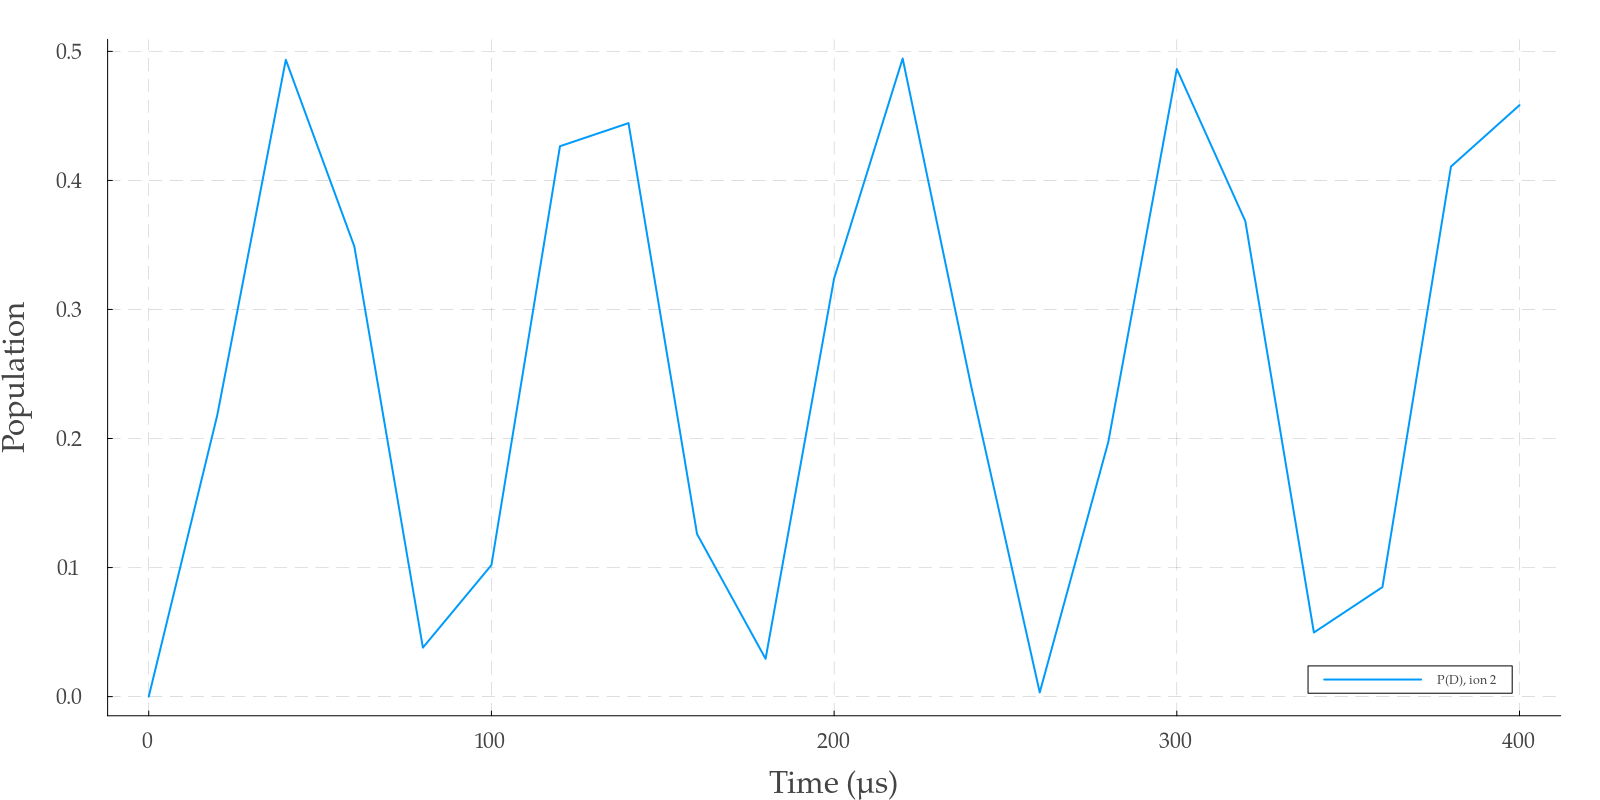

In [38]:
plt.plot(tout_deg2, P_D_deg2, label="P(D), ion 2")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
plt.show()

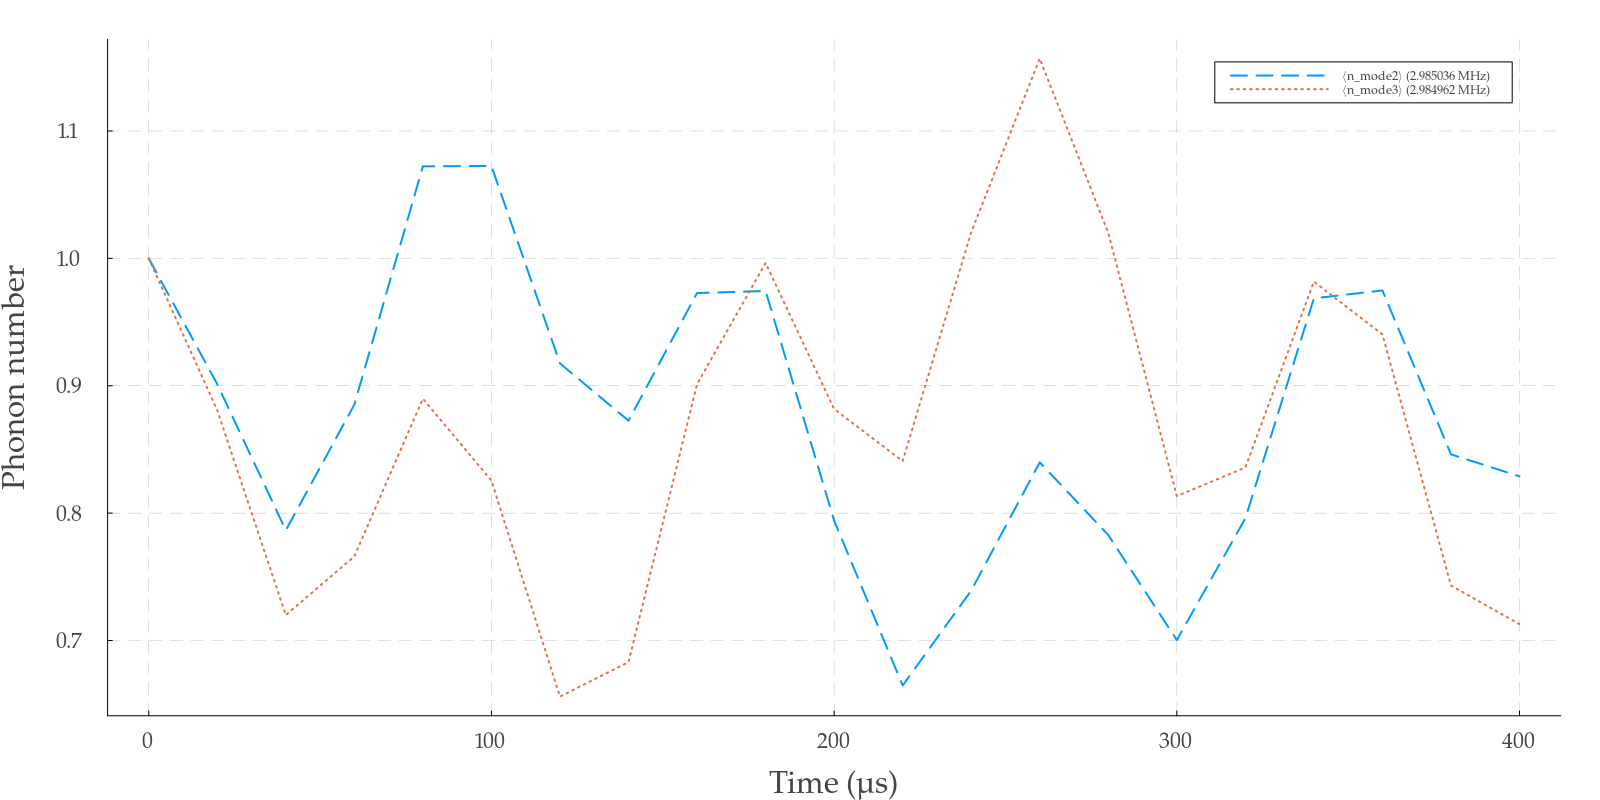

In [39]:
plt.plot(tout_deg2, n_mode2_deg2, ls="dashed", label="⟨n_mode2⟩ (2.985036 MHz)")
plt.plot(tout_deg2, n_mode3_deg2, ls="dotted", label="⟨n_mode3⟩ (2.984962 MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.show()

In [40]:
# Same idea, but for mode 4 and mode 5 (2.936844 MHz vs 2.934913 MHz — a
# ~1.9 kHz gap, wider than the mode2/mode3 pair but still tiny compared to
# the sideband coupling strength). Reuses the ion-2 chamber/laser built above.
mode4_deg, mode5_deg = xm_deg2[4], xm_deg2[5]
println("η(ion 2, mode 4) = ", lambdicke(mode4_deg, ions_deg[2], laser_deg2))
println("η(ion 2, mode 5) = ", lambdicke(mode5_deg, ions_deg[2], laser_deg2))

for (i, m) in enumerate(xm_deg2)
    modecutoff!(m, (i == 4 || i == 5) ? 3 : 0)
end

Δ_mid_deg45 = -(frequency(mode4_deg) + frequency(mode5_deg)) / 2
detuning!(laser_deg2, Δ_mid_deg45)
h_deg45 = hamiltonian(chamber_deg2, timescale=1e-6, rwa_cutoff=1.5e6, lamb_dicke_order=1)

ρ₀_deg45 = tensor([dm(ions_deg[i]["S"]) for i in 1:5]...)
mode_states_deg45 = [dm(fockstate(xm_deg2[i], (i == 4 || i == 5) ? 1 : 0)) for i in 1:5]
ρ₀_deg45 = ρ₀_deg45 ⊗ mode_states_deg45[1] ⊗ mode_states_deg45[2] ⊗ mode_states_deg45[3] ⊗ mode_states_deg45[4] ⊗ mode_states_deg45[5]

n4_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(xm_deg2[2]) ⊗ one(xm_deg2[3]) ⊗ IonSim.number(mode4_deg) ⊗ one(mode5_deg)
n5_op_deg = tensor([one(ions_deg[i]) for i in 1:5]...) ⊗ one(xm_deg2[1]) ⊗ one(xm_deg2[2]) ⊗ one(xm_deg2[3]) ⊗ one(mode4_deg) ⊗ IonSim.number(mode5_deg)
PD_op_deg45 = ionprojector(chamber_deg2, "S", "D", "S", "S", "S")

fout_deg45(t, ψ) = (
    real(expect(PD_op_deg45, ψ)),
    real(expect(n4_op_deg, ψ)),
    real(expect(n5_op_deg, ψ)),
)

tspan_deg45 = 0:20:400
tout_deg45, sol_deg45 = timeevolution.schroedinger_dynamic(tspan_deg45, ρ₀_deg45, h_deg45, fout=fout_deg45)
P_D_deg45 = [s[1] for s in sol_deg45]
n_mode4_deg45 = [s[2] for s in sol_deg45]
n_mode5_deg45 = [s[3] for s in sol_deg45]

η(ion 2, mode 4) = 0.025571376903958703
η(ion 2, mode 5) = 0.025202554672767233


21-element Vector{Float64}:
 1.0
 0.7565933207005655
 1.0132937506147435
 0.7313524370703095
 0.9264115488854859
 0.8331054653669526
 0.9133484036815831
 0.8890639905590058
 0.8301791009157967
 0.8653640063709787
 0.9009597640907021
 0.8721050409317527
 0.8789558444026031
 0.8856992443126028
 0.8801905879940417
 0.8096372612494729
 0.8551074287212924
 0.8898378693924842
 0.8768282147832612
 0.9495845911424301
 0.7323236724194226

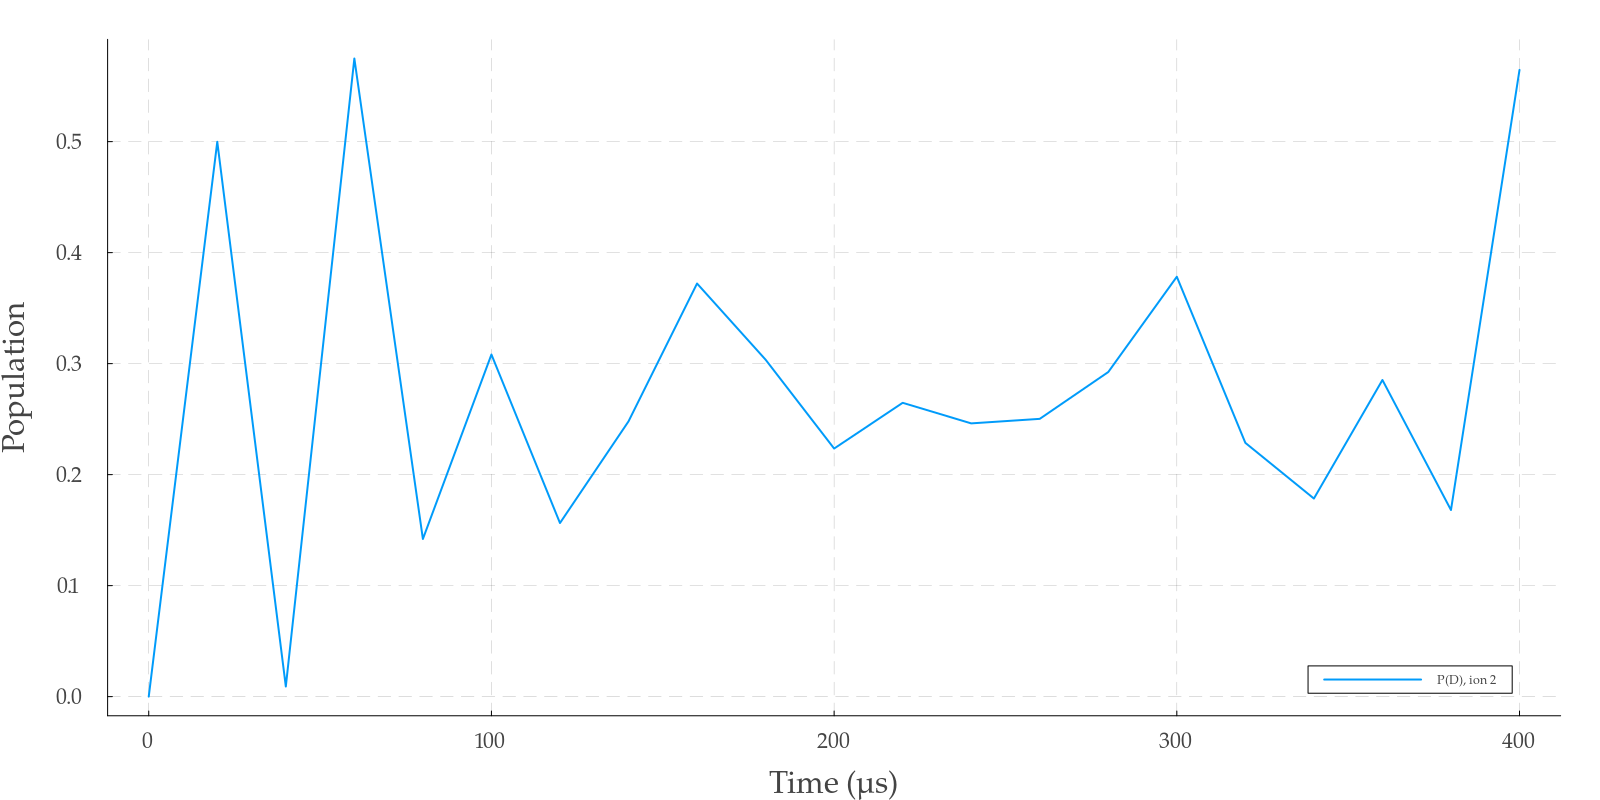

In [41]:
plt.plot(tout_deg45, P_D_deg45, label="P(D), ion 2")
plt.xlabel("Time (μs)")
plt.ylabel("Population")
plt.show()

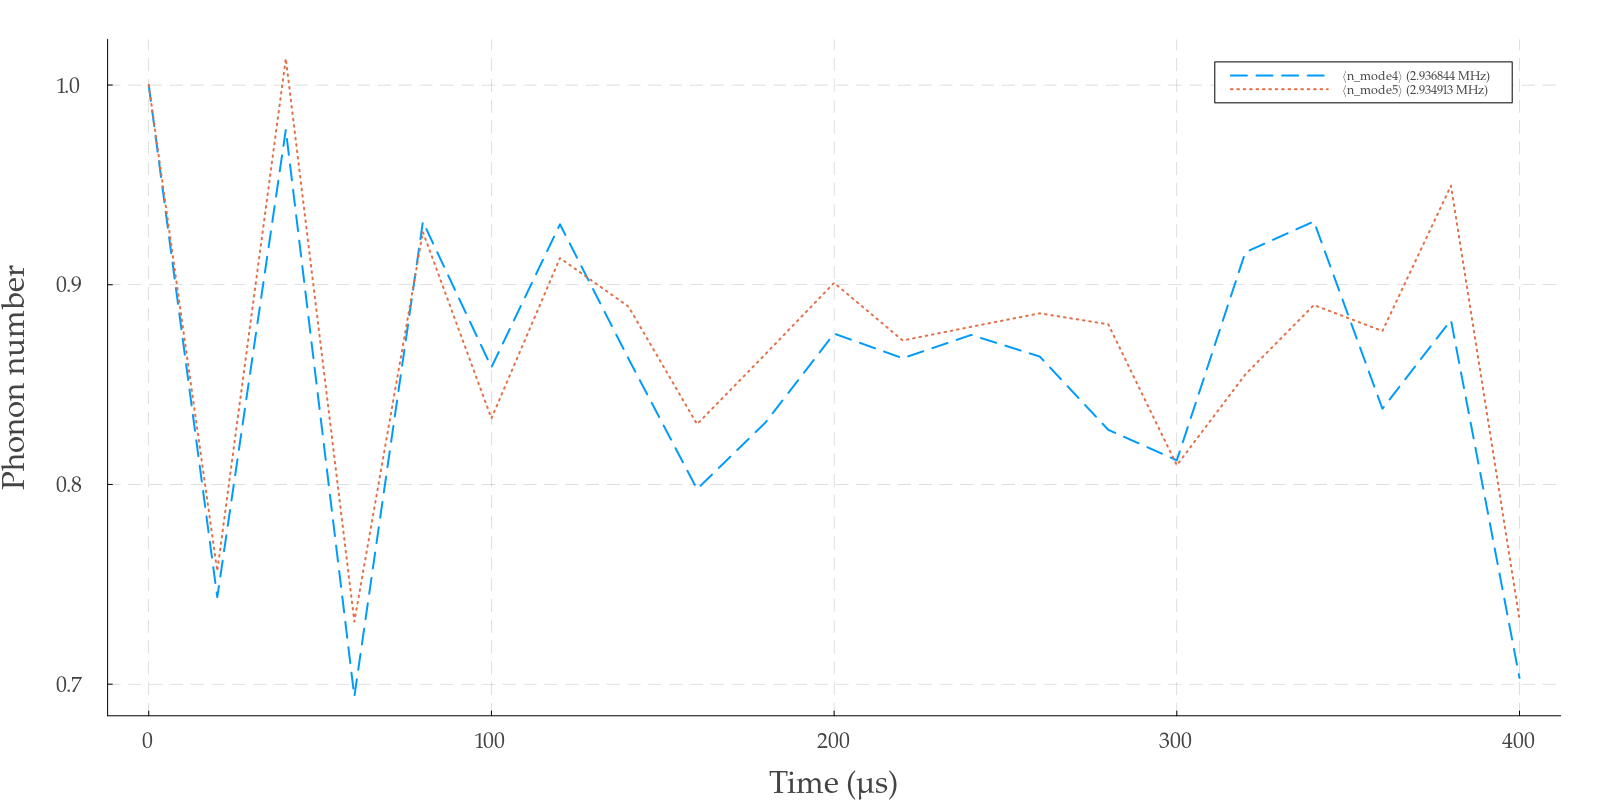

In [42]:
plt.plot(tout_deg45, n_mode4_deg45, ls="dashed", label="⟨n_mode4⟩ (2.936844 MHz)")
plt.plot(tout_deg45, n_mode5_deg45, ls="dotted", label="⟨n_mode5⟩ (2.934913 MHz)")
plt.legend(loc=1, framealpha=1)
plt.xlabel("Time (μs)")
plt.ylabel("Phonon number")
plt.show()